# CSE438 Lab 01 — Introduction to Image Processing Tools with Python

**Course:** CSE438 Digital Image Processing  
**Week:** 1  
**CO Mapping:** CO1, CO4  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Instructor:** Dr. Md. Rifat Ahmmad Rashid  

This lab introduces the basic Python environment for digital image processing. The notebook uses a real agricultural image dataset so that students can connect array-level image representation with a practical computer vision dataset.

## 1. Learning Objectives

After completing this lab, students should be able to:

1. verify a Python image-processing environment in Kaggle;
2. load color and grayscale images using OpenCV;
3. display images correctly using Matplotlib;
4. inspect image shape, data type, channel structure, and pixel intensity values;
5. convert images between BGR, RGB, and grayscale formats;
6. save processed images to the Kaggle working directory.

## 2. Lab Task Map

| Task | Activity | Expected Output |
|---|---|---|
| Task 1 | Verify Python, NumPy, OpenCV, Matplotlib, and Pandas | Library versions printed |
| Task 2 | Locate the Kaggle dataset and inspect class folders | Class names and image counts |
| Task 3 | Load a grayscale and a color image | Valid image arrays |
| Task 4 | Display image shape, dtype, channel count, and pixel values | Structured image-property table |
| Task 5 | Convert between BGR, RGB, and grayscale | Correctly displayed converted images |
| Task 6 | Save processed images | Output files in `/kaggle/working/cse438_lab01_outputs` |

**Important Kaggle note:** Add the dataset `rifat963/betel-leaf-image-dataset-from-bangladesh` to the notebook using **Add Data** before running this notebook.

## 3. Environment Verification and Library Imports

In [1]:
# Core numerical and image-processing libraries
import os
import sys
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Keep plots visible inside the notebook.
%matplotlib inline

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Python: 3.12.12
NumPy: 2.0.2
OpenCV: 4.13.0
Pandas: 2.3.3
Matplotlib: 3.10.0


## 4. Dataset Configuration

The user-provided folder structure is:

```text
/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/<class_name>
/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test/<class_name>
```

In Kaggle notebooks, the mounted folder may also appear as:

```text
/kaggle/input/betel-leaf-image-dataset-from-bangladesh/train/<class_name>
/kaggle/input/betel-leaf-image-dataset-from-bangladesh/test/<class_name>
```

The following cell checks both possibilities and then searches `/kaggle/input` for a directory that contains both `train` and `test` folders.

In [2]:
EXPECTED_CLASSES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

CANDIDATE_DATASET_ROOTS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def locate_dataset_root(candidate_roots=None):
    """
    Locate the dataset root that contains both train/ and test/ folders.

    The function first checks known paths. If these paths are not available,
    it searches under /kaggle/input for a folder whose train directory contains
    the expected four class names.
    """
    candidate_roots = candidate_roots or CANDIDATE_DATASET_ROOTS

    for root in candidate_roots:
        if (root / "train").exists() and (root / "test").exists():
            return root

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for train_dir in kaggle_input.rglob("train"):
            possible_root = train_dir.parent
            test_dir = possible_root / "test"

            if not test_dir.exists():
                continue

            class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
            if set(EXPECTED_CLASSES).issubset(set(class_names)):
                return possible_root

    raise FileNotFoundError(
        "Dataset root was not found. Attach the Kaggle dataset "
        "'rifat963/betel-leaf-image-dataset-from-bangladesh' using Add Data, "
        "then rerun this cell."
    )


DATASET_ROOT = locate_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"
OUTPUT_DIR = Path("/kaggle/working/cse438_lab01_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)
print("Output folder:", OUTPUT_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train folder: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test folder: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test
Output folder: /kaggle/working/cse438_lab01_outputs


## 5. Inspect Dataset Folders and Class Distribution

In [3]:
def list_image_files(folder):
    """
    Return a sorted list of image files from a directory.
    """
    folder = Path(folder)
    return sorted([
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ])


def build_class_summary(split_dir):
    """
    Build a table showing the number of images in each class folder.
    """
    records = []

    for class_name in EXPECTED_CLASSES:
        class_dir = split_dir / class_name
        image_files = list_image_files(class_dir) if class_dir.exists() else []

        records.append({
            "split": split_dir.name,
            "class_name": class_name,
            "folder_exists": class_dir.exists(),
            "image_count": len(image_files),
            "folder_path": str(class_dir),
        })

    return pd.DataFrame(records)


train_summary = build_class_summary(TRAIN_DIR)
test_summary = build_class_summary(TEST_DIR)
dataset_summary = pd.concat([train_summary, test_summary], ignore_index=True)

display(dataset_summary)

if dataset_summary["image_count"].sum() == 0:
    raise RuntimeError("No image files were found. Check the dataset mount path and file extensions.")

,split,class_name,folder_exists,image_count,folder_path
0,train,Bacterial Leaf Disease,True,609,/kaggle/input/datasets/rifat963/betel-leaf-ima...
1,train,Dried Leaf,True,597,/kaggle/input/datasets/rifat963/betel-leaf-ima...
2,train,Fungal Brown Spot Disease,True,588,/kaggle/input/datasets/rifat963/betel-leaf-ima...
3,train,Healthy Leaf,True,594,/kaggle/input/datasets/rifat963/betel-leaf-ima...
4,test,Bacterial Leaf Disease,True,47,/kaggle/input/datasets/rifat963/betel-leaf-ima...
5,test,Dried Leaf,True,51,/kaggle/input/datasets/rifat963/betel-leaf-ima...
6,test,Fungal Brown Spot Disease,True,54,/kaggle/input/datasets/rifat963/betel-leaf-ima...
7,test,Healthy Leaf,True,49,/kaggle/input/datasets/rifat963/betel-leaf-ima...


## 6. Select Example Images

For this introductory lab, one representative image is selected from each class in the training set. Later labs can use the same helper functions for histogram analysis, filtering, segmentation, and morphology.

In [4]:
def get_first_image_per_class(split_dir, class_names):
    """
    Select the first available image from each class.
    """
    selected = {}

    for class_name in class_names:
        class_dir = split_dir / class_name
        image_files = list_image_files(class_dir)

        if len(image_files) == 0:
            print(f"Warning: no image found for class: {class_name}")
            continue

        selected[class_name] = image_files[0]

    return selected


sample_paths = get_first_image_per_class(TRAIN_DIR, EXPECTED_CLASSES)

for class_name, image_path in sample_paths.items():
    print(f"{class_name:30s} -> {image_path}")

Bacterial Leaf Disease         -> /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Bacterial Leaf Disease/Bacterial_Leaf_Spot_Disease-1-_jpg.rf.0f57aad42a8a1da8d916d82813dab61d.jpg
Dried Leaf                     -> /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Dried Leaf/Dried_Leaf-100-_jpg.rf.7ccdfca94feee62fd0dcfe5d317b45b4.jpg
Fungal Brown Spot Disease      -> /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Fungal Brown Spot Disease/Fungal_Brown_Spot_Disease-1-_jpg.rf.155fcc8536289fb43f2a2a5fddc09e6c.jpg
Healthy Leaf                   -> /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg


## 7. Helper Functions for Image Loading and Display

In [5]:
def read_image_bgr(image_path):
    """
    Read a color image using OpenCV.

    OpenCV loads color images in BGR channel order.
    Matplotlib expects RGB channel order.
    """
    image_path = str(image_path)
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"OpenCV could not read the image: {image_path}")

    return image_bgr


def read_image_gray(image_path):
    """
    Read an image directly as a single-channel grayscale image.
    """
    image_path = str(image_path)
    image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image_gray is None:
        raise ValueError(f"OpenCV could not read the grayscale image: {image_path}")

    return image_gray


def bgr_to_rgb(image_bgr):
    """
    Convert OpenCV BGR image to Matplotlib-compatible RGB image.
    """
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def show_image(image, title="", cmap=None, axis_off=True):
    """
    Display a single image with Matplotlib.
    """
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    if axis_off:
        plt.axis("off")
    plt.show()


def show_image_grid(images, titles, cmap=None, columns=4, figsize=(14, 7)):
    """
    Display multiple images in a compact grid.
    """
    rows = int(np.ceil(len(images) / columns))
    plt.figure(figsize=figsize)

    for idx, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, columns, idx)
        plt.imshow(image, cmap=cmap)
        plt.title(title, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 8. Display Sample Images from the Four Classes

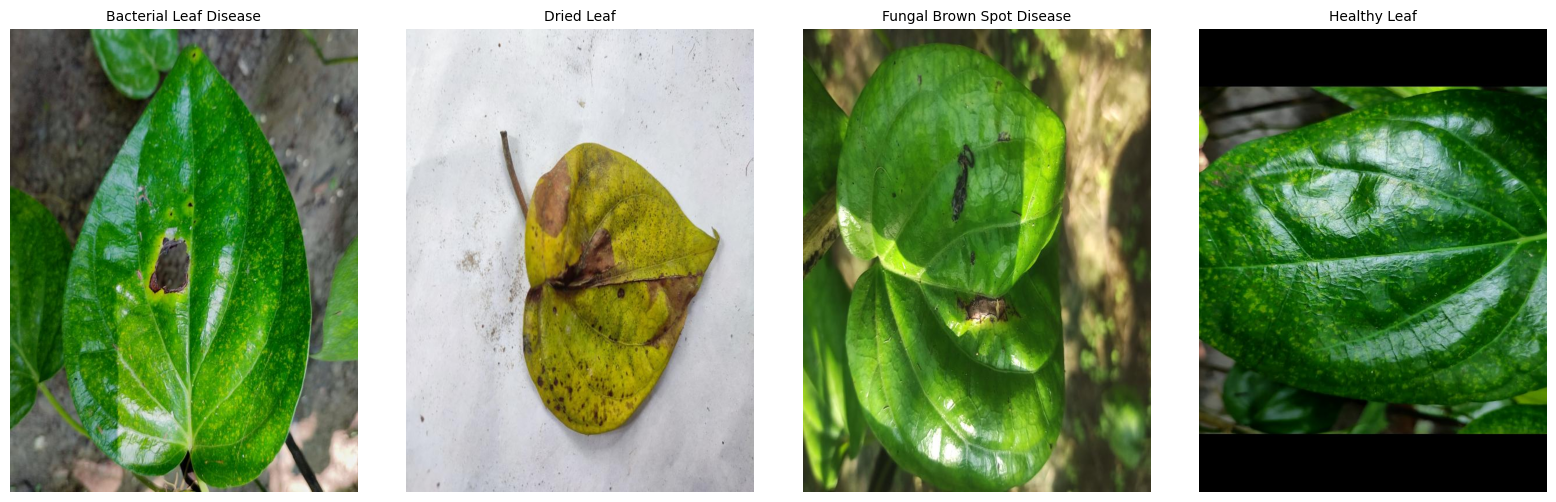

In [6]:
sample_rgb_images = []
sample_titles = []

for class_name, image_path in sample_paths.items():
    image_bgr = read_image_bgr(image_path)
    image_rgb = bgr_to_rgb(image_bgr)

    sample_rgb_images.append(image_rgb)
    sample_titles.append(class_name)

show_image_grid(sample_rgb_images, sample_titles, columns=4, figsize=(16, 5))

## 9. Load One Color Image and One Grayscale Image

The following cell selects the first available training image. The same file is loaded twice:

- once as a color image using `cv2.IMREAD_COLOR`;
- once as a grayscale image using `cv2.IMREAD_GRAYSCALE`.

This makes the channel difference visible at the array level.

Selected class: Bacterial Leaf Disease
Selected image path: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Bacterial Leaf Disease/Bacterial_Leaf_Spot_Disease-1-_jpg.rf.0f57aad42a8a1da8d916d82813dab61d.jpg


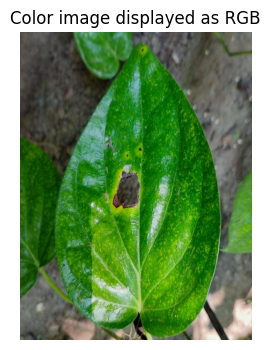

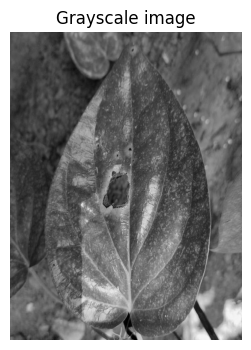

In [7]:
# Select a reproducible image for detailed inspection.
selected_class = EXPECTED_CLASSES[0]
selected_image_path = sample_paths[selected_class]

image_bgr = read_image_bgr(selected_image_path)
image_rgb = bgr_to_rgb(image_bgr)
image_gray = read_image_gray(selected_image_path)

print("Selected class:", selected_class)
print("Selected image path:", selected_image_path)

show_image(image_rgb, title="Color image displayed as RGB")
show_image(image_gray, title="Grayscale image", cmap="gray")

## 10. Inspect Image Shape, Data Type, and Channel Structure

In [8]:
def describe_image(image, name):
    """
    Return image properties as a dictionary.
    """
    if image.ndim == 2:
        height, width = image.shape
        channels = 1
    elif image.ndim == 3:
        height, width, channels = image.shape
    else:
        height, width, channels = None, None, None

    return {
        "image_name": name,
        "shape": image.shape,
        "height": height,
        "width": width,
        "channels": channels,
        "dtype": image.dtype,
        "min_pixel_value": int(image.min()),
        "max_pixel_value": int(image.max()),
        "mean_pixel_value": float(np.mean(image)),
    }


image_properties = pd.DataFrame([
    describe_image(image_bgr, "Color image loaded by OpenCV (BGR)"),
    describe_image(image_rgb, "Color image converted for Matplotlib (RGB)"),
    describe_image(image_gray, "Grayscale image"),
])

display(image_properties)

,image_name,shape,height,width,channels,dtype,min_pixel_value,max_pixel_value,mean_pixel_value
0,Color image loaded by OpenCV (BGR),"(800, 600, 3)",800,600,3,uint8,0,255,79.381791
1,Color image converted for Matplotlib (RGB),"(800, 600, 3)",800,600,3,uint8,0,255,79.381791
2,Grayscale image,"(800, 600)",800,600,1,uint8,0,252,94.545052


### Interpretation Note

For a standard 8-bit image, pixel values usually range from 0 to 255.  
A color image has three channels, while a grayscale image has one intensity value per pixel.

## 11. Display Pixel Values from a Small Image Region

In [9]:
# Select a small 5 x 5 patch from the top-left corner of the grayscale image.
gray_patch = image_gray[:5, :5]

print("5 x 5 grayscale patch:")
display(pd.DataFrame(gray_patch))

# Select one pixel from the color image.
row, col = 10, 10

bgr_pixel = image_bgr[row, col]
rgb_pixel = image_rgb[row, col]
gray_pixel = image_gray[row, col]

pixel_table = pd.DataFrame([
    {
        "location": f"row={row}, col={col}",
        "BGR_pixel_from_OpenCV": bgr_pixel.tolist(),
        "RGB_pixel_for_Matplotlib": rgb_pixel.tolist(),
        "grayscale_intensity": int(gray_pixel),
    }
])

display(pixel_table)

5 x 5 grayscale patch:


,0,1,2,3,4
0,86,84,81,78,77
1,86,84,80,77,76
2,85,82,79,76,75
3,83,80,77,75,75
4,79,78,75,74,76


,location,BGR_pixel_from_OpenCV,RGB_pixel_for_Matplotlib,grayscale_intensity
0,"row=10, col=10","[83, 88, 91]","[91, 88, 83]",88


## 12. Compare BGR and RGB Display

A common beginner error is to display an OpenCV BGR image directly with Matplotlib. The following comparison shows why channel conversion is necessary.

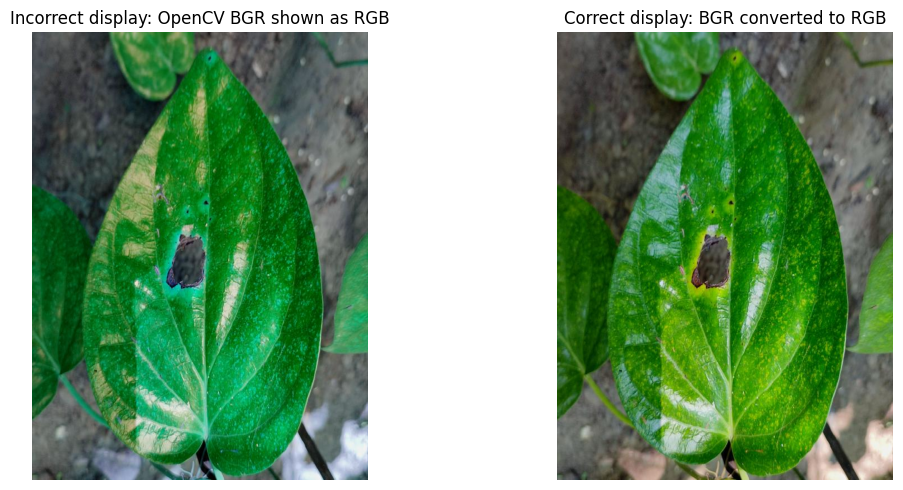

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_bgr)
plt.title("Incorrect display: OpenCV BGR shown as RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_rgb)
plt.title("Correct display: BGR converted to RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Convert Between Color and Grayscale

Original BGR shape: (800, 600, 3)
Converted grayscale shape: (800, 600)
Grayscale converted back to 3-channel shape: (800, 600, 3)


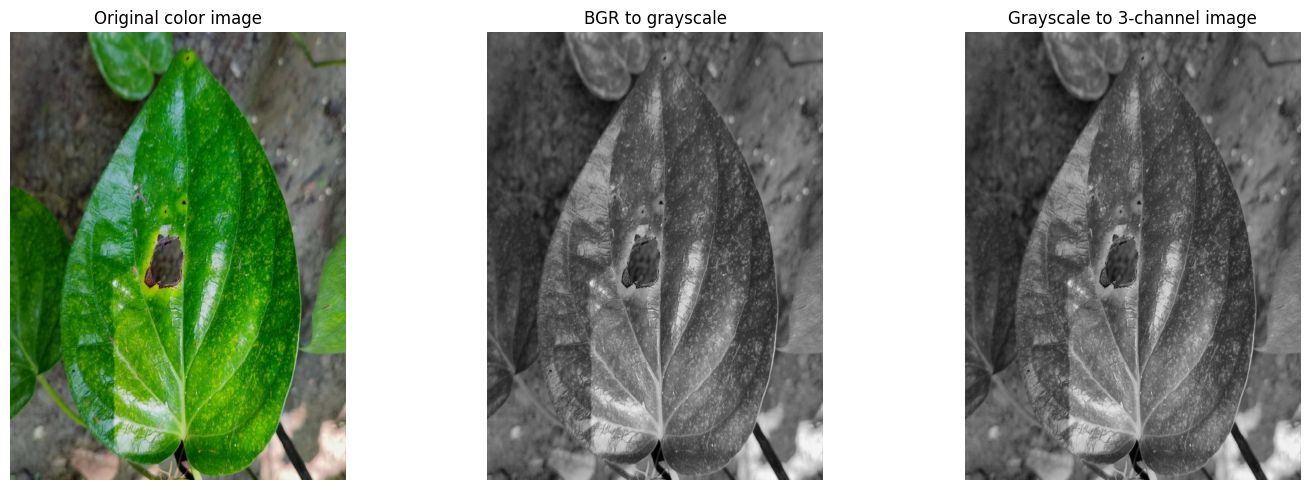

In [11]:
# Convert BGR color image to grayscale after loading as color.
gray_from_bgr = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# Convert grayscale to pseudo-color BGR format.
# This does not recover original color. It only creates three identical channels.
bgr_from_gray = cv2.cvtColor(gray_from_bgr, cv2.COLOR_GRAY2BGR)
rgb_from_gray = bgr_to_rgb(bgr_from_gray)

print("Original BGR shape:", image_bgr.shape)
print("Converted grayscale shape:", gray_from_bgr.shape)
print("Grayscale converted back to 3-channel shape:", bgr_from_gray.shape)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original color image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_from_bgr, cmap="gray")
plt.title("BGR to grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_from_gray)
plt.title("Grayscale to 3-channel image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Resize and Save Processed Images

Kaggle allows writing files to `/kaggle/working`. The saved outputs can be downloaded from the notebook output panel after execution.

In [12]:
# Resize the image for a small processed output.
resized_rgb = cv2.resize(image_rgb, (256, 256), interpolation=cv2.INTER_AREA)
resized_bgr = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR)

color_output_path = OUTPUT_DIR / "lab01_color_resized_256.png"
gray_output_path = OUTPUT_DIR / "lab01_grayscale.png"
patch_output_path = OUTPUT_DIR / "lab01_gray_patch_5x5.csv"

# cv2.imwrite expects BGR for color images.
cv2.imwrite(str(color_output_path), resized_bgr)
cv2.imwrite(str(gray_output_path), gray_from_bgr)
pd.DataFrame(gray_patch).to_csv(patch_output_path, index=False)

print("Saved files:")
print(color_output_path)
print(gray_output_path)
print(patch_output_path)

print("\nFiles currently available in output folder:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Saved files:
/kaggle/working/cse438_lab01_outputs/lab01_color_resized_256.png
/kaggle/working/cse438_lab01_outputs/lab01_grayscale.png
/kaggle/working/cse438_lab01_outputs/lab01_gray_patch_5x5.csv

Files currently available in output folder:
- lab01_color_resized_256.png
- lab01_gray_patch_5x5.csv
- lab01_grayscale.png


## 15. Verify Saved Images

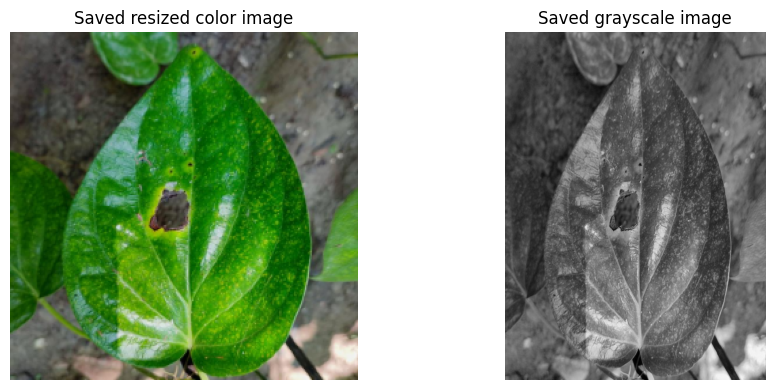

In [13]:
saved_color_bgr = read_image_bgr(color_output_path)
saved_gray = read_image_gray(gray_output_path)

saved_color_rgb = bgr_to_rgb(saved_color_bgr)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(saved_color_rgb)
plt.title("Saved resized color image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(saved_gray, cmap="gray")
plt.title("Saved grayscale image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Student Practice Tasks

Complete the following exercises by modifying the code cells above.

1. Select one image from each of the four classes and report its shape, dtype, and channel count.
2. Display the first 10 × 10 grayscale pixel values for one image.
3. Convert one image from BGR to RGB and then to grayscale.
4. Save the grayscale image and resized color image to the output folder.
5. Write two observations about how the pixel values differ between color and grayscale representations.

## Summary:
- In this lab, we loaded image data from the Betel Leaf dataset, inspected image properties,
- converted images between color formats, visualized sample outputs, and saved processed images.
- These steps establish the basic workflow required for future Digital Image Processing labs.